# Multivariate quantiles and long horizon forecasting with N-HiTS
This nb was taken from [the PyTorch Forecasting documentation.](https://pytorch-forecasting.readthedocs.io/en/stable/tutorials/nhits.html)

We recommend running it here [https://colab.research.google.com/github/vrodriguezf/sertemp/blob/main/nbs/forecasting/NHiTS.ipynb](https://colab.research.google.com/github/vrodriguezf/sertemp/blob/main/nbs/forecasting/NHiTS.ipynb)


In [11]:
# install dependencies:
#!pip install lightning pytorch_forecasting cpflows

In [1]:
# CELL 1 - run this first, before any other imports
import torch._tensor  # force torch internals to load
from torch.serialization import load as _actual_load  # grab the real function directly

import lightning.fabric.utilities.cloud_io as cloud_io

def patched_load(*args, **kwargs):
    kwargs["weights_only"] = False
    return _actual_load(*args, **kwargs)

cloud_io.torch.load = patched_load

In [2]:
import os
import warnings

warnings.filterwarnings("ignore")

os.chdir("../../..")

In [3]:
# Install the dependencies --> lightning and pytorch-forecasting
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from litlogger import *


from pytorch_forecasting import Baseline, NHiTS, TimeSeriesDataSet
from pytorch_forecasting.data import NaNLabelEncoder
from pytorch_forecasting.data.examples import generate_ar_data
from pytorch_forecasting.metrics import MAE, SMAPE, MQF2DistributionLoss, QuantileLoss

import torch
torch.set_float32_matmul_precision('high')

## Load data


We generate a synthetic dataset to demonstrate the network's capabilities. The data consists of a quadratic trend and a seasonality component.


In [4]:
data = generate_ar_data(seasonality=10.0, timesteps=400, n_series=100, seed=42)
data["static"] = 2
data["date"] = pd.Timestamp("2020-01-01") + pd.to_timedelta(data.time_idx, "D")
data.head()

,series,time_idx,value,static,date
0,0,0,-0.000000,2,2020-01-01
1,0,1,-0.046501,2,2020-01-02
2,0,2,-0.097796,2,2020-01-03
3,0,3,-0.144397,2,2020-01-04
4,0,4,-0.177954,2,2020-01-05


Before starting training, we need to split the dataset into a training and validation :py:class:`~pytorch_forecasting.data.timeseries.TimeSeriesDataSet`.

In [5]:
# create dataset and dataloaders
max_encoder_length = 60
max_prediction_length = 20

training_cutoff = data["time_idx"].max() - max_prediction_length

context_length = max_encoder_length
prediction_length = max_prediction_length

training = TimeSeriesDataSet(
    data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="value",
    categorical_encoders={"series": NaNLabelEncoder().fit(data.series)},
    group_ids=["series"],
    # only unknown variable is "value" - and N-HiTS can also not take any additional variables
    time_varying_unknown_reals=["value"],
    max_encoder_length=context_length,
    max_prediction_length=prediction_length,
)

validation = TimeSeriesDataSet.from_dataset(training, data, min_prediction_idx=training_cutoff + 1)
batch_size = 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

## Calculate baseline error


Our baseline model predicts future values by repeating the last know value. The resulting :py:class:`~pytorch_forecasting.metrics.SMAPE` is disappointing and should not be easy to beat.

In [6]:
# calculate baseline absolute error
baseline_predictions = Baseline().predict(
    val_dataloader,
    trainer_kwargs=dict(
        accelerator="cuda",
        logger=False,
        enable_checkpointing=False
    ),
    return_y=True
)
SMAPE()(
    baseline_predictions.output.cpu(),
    baseline_predictions.y[0].cpu()  # .y devuelve una tupla (target, weight)
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


tensor(0.5462)

## Train network


Finding the optimal learning rate using [PyTorch Lightning](https://pytorch-lightning.readthedocs.io/) is easy. The key hyperparameter of the :py:class:`~pytorch_forecasting.models.nhits.NHiTS` model is ``hidden_size``.

PyTorch Forecasting is flexible enough to use NHiTS with different loss functions, enabling not only point forecasts but also probabilistic ones. Here, we will demonstrate not only a typical quantile regression but a multivariate quantile regression with :py:class:`~pytorch_forecasting.metrics.distributions.MQF2DistributionLoss` which allows calculation sampling consistent paths along a prediction horizon. This allows calculation of quantiles, e.g. of the sum over the prediction horizon while still avoiding the accumulating error problem from auto-regressive methods such as DeepAR. One needs to install an additional package for this quantile function:

``pip install pytorch-forecasting[mqf2]``

In [8]:
DIR = os.path.join(os.path.expanduser("~"), "lightning_logs")

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.
Finding best initial lr: 100%|██████████| 100/100 [00:11<00:00,  8.50it/s]
Restoring states from the checkpoint path at /home/eder/lightning_logs/.lr_find_85814c5e-6f23-408c-aea7-0268768a4011.ckpt
Restored all states from the checkpoint at /home/eder/lightning_logs/.lr_find_85814c5e-6f23-408c-aea7-0268768a4011.ckpt
Learning rate set to 3.630780547701014e-05


suggested learning rate: 3.630780547701014e-05


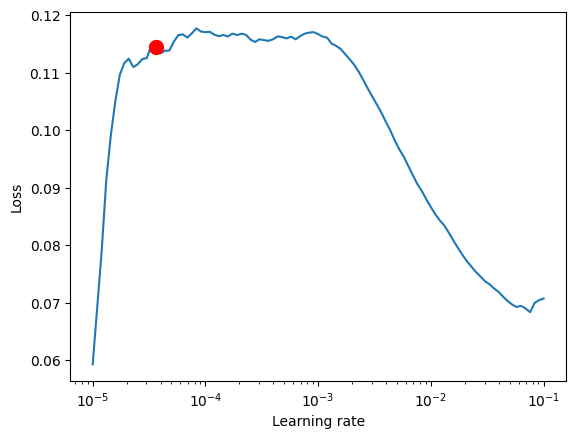

In [9]:
import lightning.pytorch as pl
from lightning.pytorch.tuner import Tuner
from pytorch_forecasting.models import NHiTS
from pytorch_forecasting.metrics import MQF2DistributionLoss

pl.seed_everything(42)
trainer = pl.Trainer(
    accelerator="cuda",
    gradient_clip_val=0.1,
    default_root_dir=DIR,
)
net = NHiTS.from_dataset(
    training,
    learning_rate=3e-2,
    weight_decay=1e-2,
    loss=MQF2DistributionLoss(prediction_length=max_prediction_length),
    backcast_loss_ratio=0.0,
    hidden_size=64,
    optimizer="AdamW",
)

res = Tuner(trainer).lr_find(
    net, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader, min_lr=1e-5, max_lr=1e-1
)
print(f"suggested learning rate: {res.suggestion()}")
fig = res.plot(show=True, suggest=True)
fig.show()
net.hparams.learning_rate = res.suggestion()

Fit model


In [10]:
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
trainer = pl.Trainer(
    max_epochs=5,
    accelerator="cuda",
    enable_model_summary=True,
    gradient_clip_val=1.0,
    callbacks=[early_stop_callback],
    limit_train_batches=30,
    enable_checkpointing=True,
)


net = NHiTS.from_dataset(
    training,
    learning_rate=5e-3,
    log_interval=10,
    log_val_interval=1,
    weight_decay=1e-2,
    backcast_loss_ratio=0.0,
    hidden_size=64,
    optimizer="AdamW",
    loss=MQF2DistributionLoss(prediction_length=max_prediction_length),
)

trainer.fit(
    net,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss            │ MQF2DistributionLoss │  5.1 K │ train │     0 │
│ 1 │ logging_metrics │ ModuleList           │      0 │ train │     0 │
│ 2 │ embeddings      │ MultiEmbedding       │      0 │ train │     0 │
│ 3 │ model           │ NHiTS                │ 35.7 K │ train │     0 │
└───┴─────────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 40.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 40.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=5` reached.


### Evaluate Results


In [11]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_model = NHiTS.load_from_checkpoint(best_model_path)

We predict on the validation dataset with :py:meth:`~pytorch_forecasting.models.base_model.BaseModel.predict` and calculate the error which is well below the baseline error

In [14]:
predictions = best_model.predict(val_dataloader, trainer_kwargs=dict(accelerator="cuda"), return_y=True)
MAE()(predictions.output.cpu(), predictions.y[0].cpu())

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


tensor(0.1987)

Looking at random samples from the validation set is always a good way to understand if the forecast is reasonable - and it is!


In [15]:
raw_predictions = best_model.predict(val_dataloader, mode="raw", return_x=True, trainer_kwargs=dict(accelerator="cuda"))

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


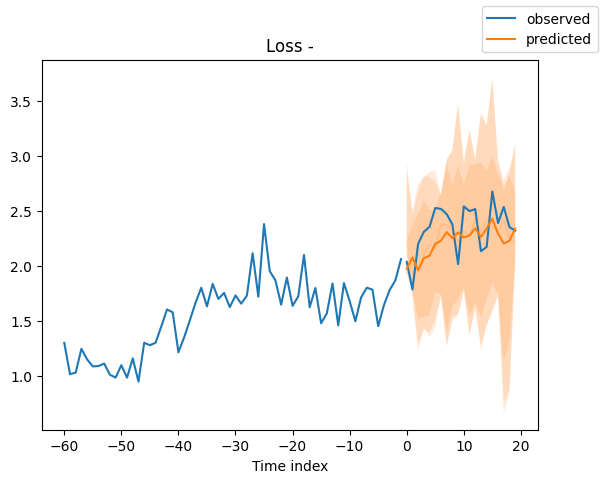

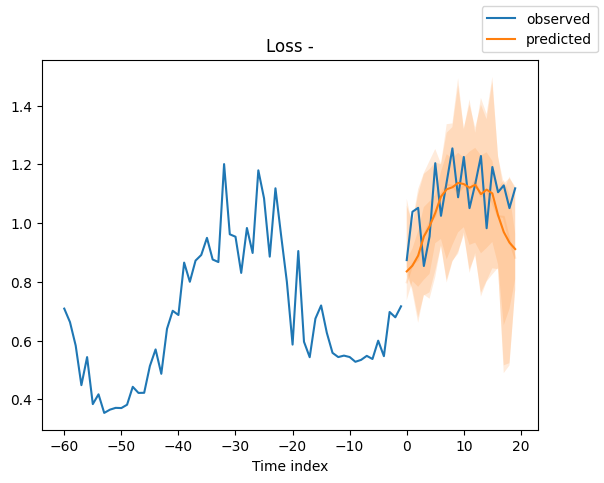

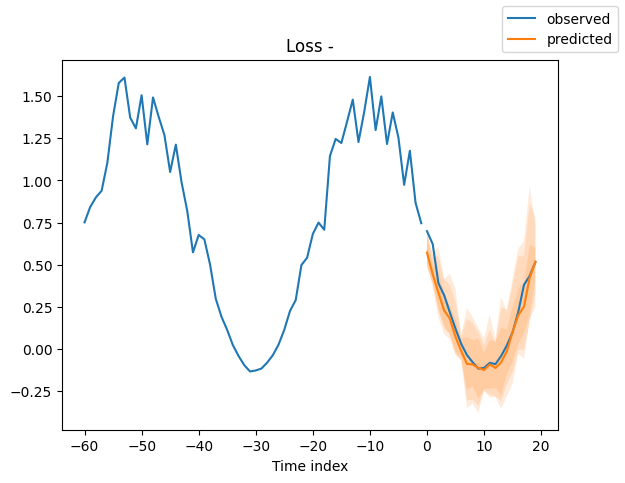

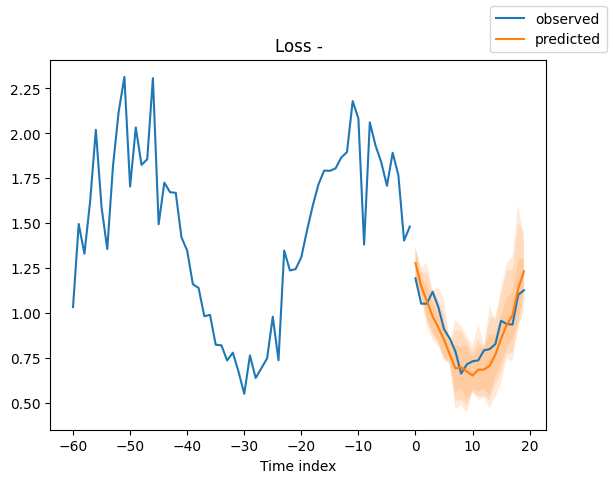

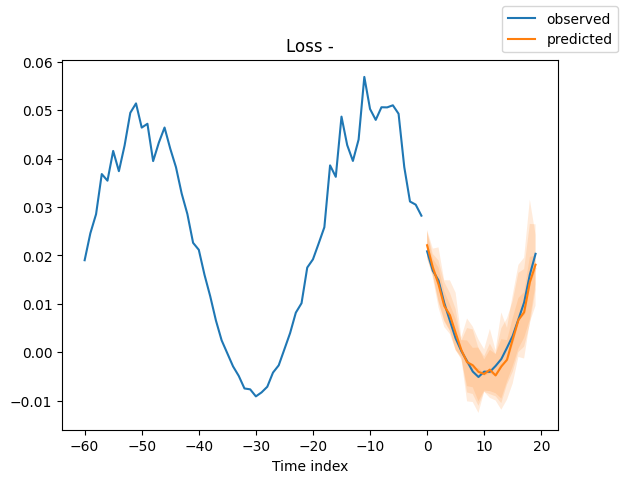

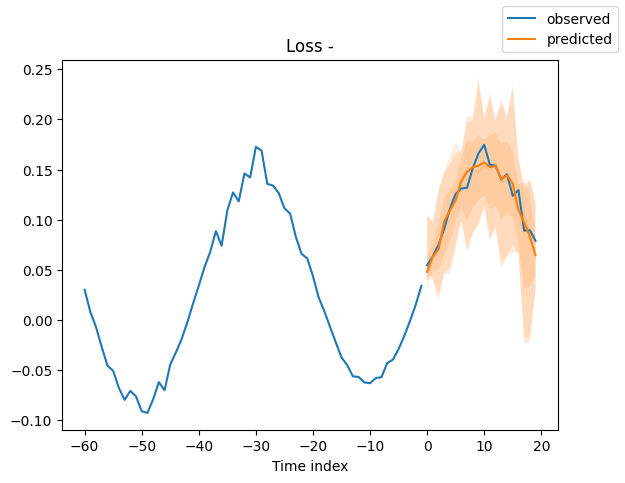

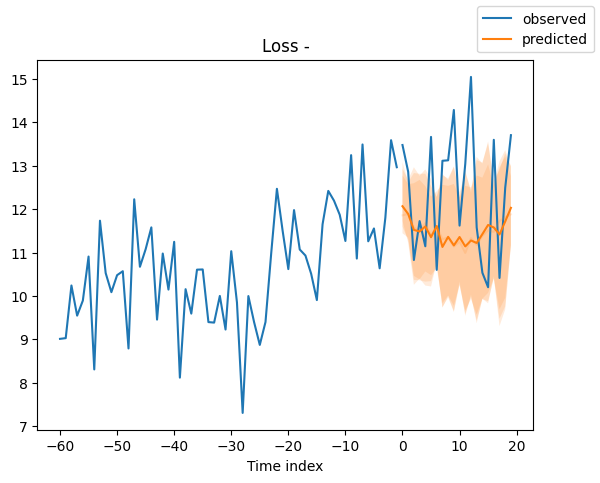

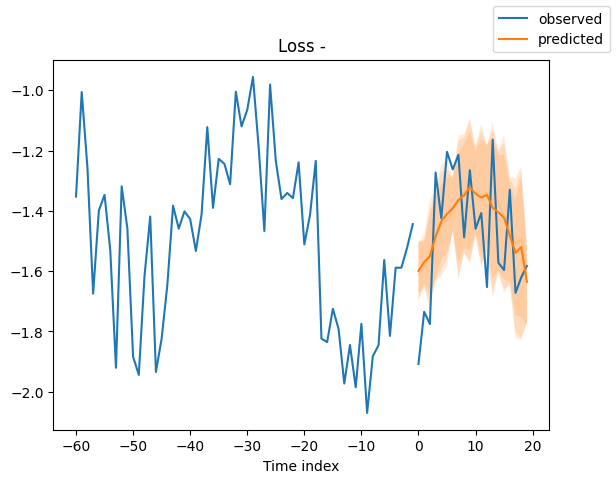

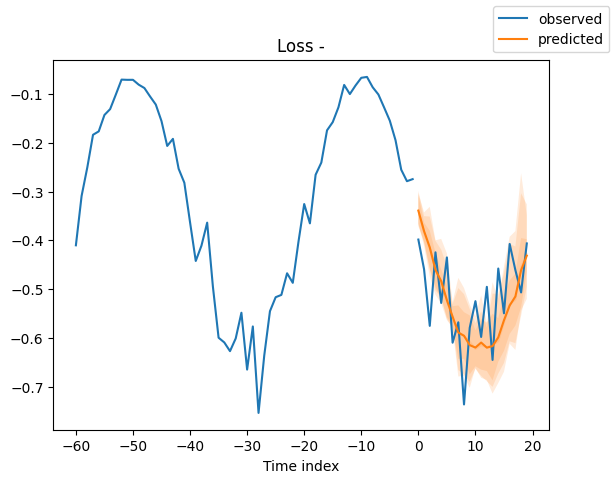

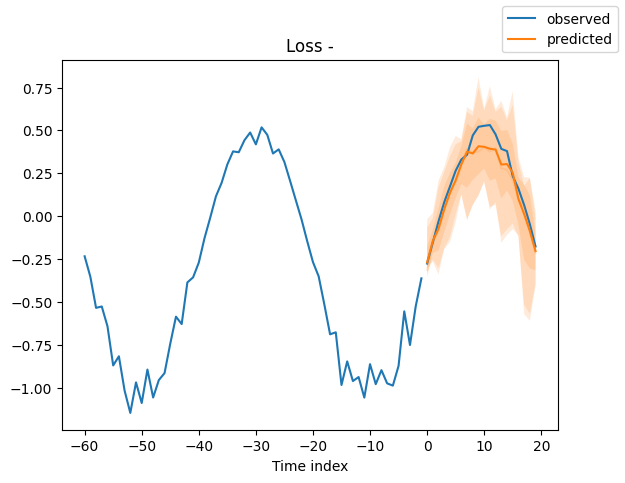

In [16]:
for idx in range(10):  # plot 10 examples
    best_model.plot_prediction(raw_predictions.x, raw_predictions.output, idx=idx, add_loss_to_title=True)

## Interpret model


We can ask PyTorch Forecasting to decompose the prediction into blocks which focus on a different frequency spectrum, e.g. seasonality and trend with :py:meth:`~pytorch_forecasting.models.nhits.NHiTS.plot_interpretation`. This is a special feature of the :py:class:`~pytorch_forecasting.models.nhits.NHiTS` model and only possible because of its unique architecture. The results show that there seem to be many ways to explain the data and the algorithm does not always chooses the one making intuitive sense. This is partially down to the small number of time series we trained on (100). But it is also due because our forecasting period does not cover multiple seasonalities.

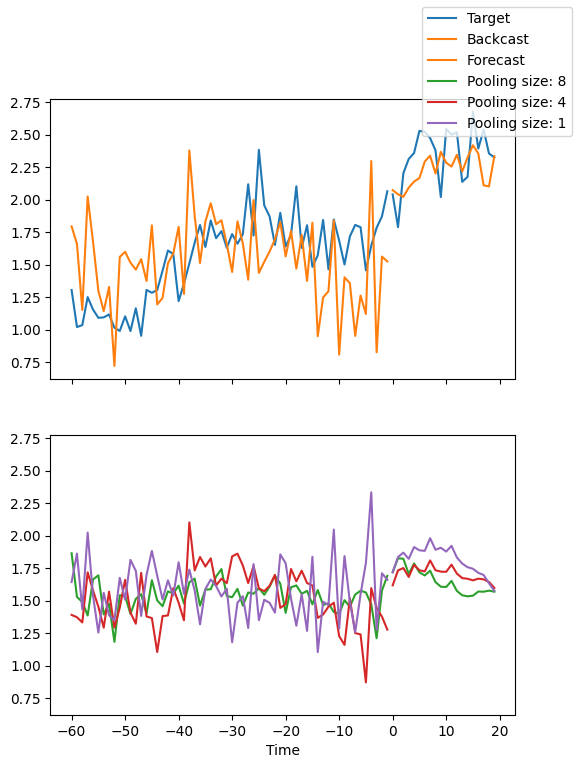

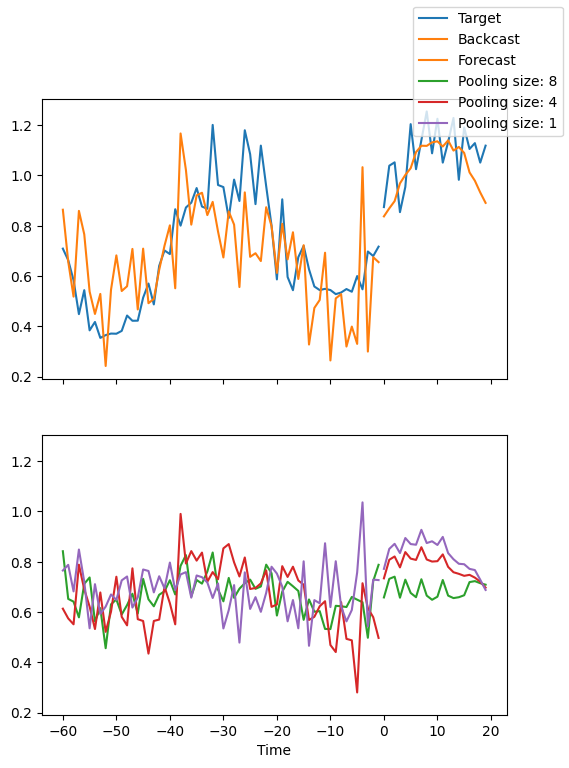

In [17]:
for idx in range(2):  # plot 10 examples
    best_model.plot_interpretation(raw_predictions.x, raw_predictions.output, idx=idx)

## Sampling from predictions


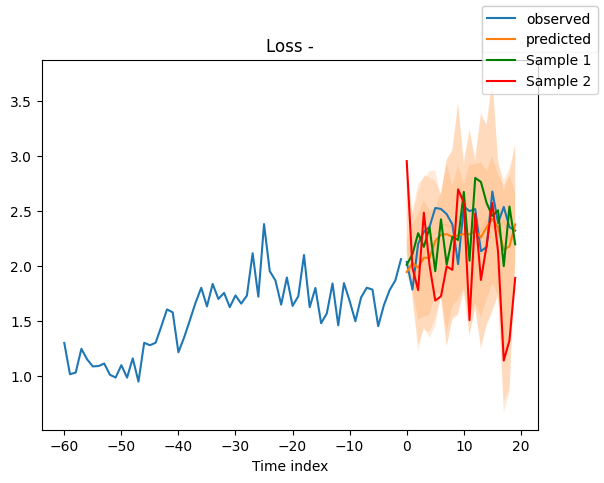

In [30]:
# sample 500 paths
samples = best_model.loss.sample(raw_predictions.output["prediction"][[0]], n_samples=500)[0]

# plot prediction
fig = best_model.plot_prediction(raw_predictions.x, raw_predictions.output, idx=0, add_loss_to_title=True)
ax = fig.get_axes()[0]
# plot first two sampled paths
samples = samples.cpu()
ax.plot(samples[:, 0], color="g", label="Sample 1")
ax.plot(samples[:, 1], color="r", label="Sample 2")
fig.legend()

As expected, the variance of predictions is smaller within each sample than accross all samples.


In [31]:
print(f"Var(all samples) = {samples.var():.4f}")
print(f"Mean(Var(sample)) = {samples.var(0).mean():.4f}")

Var(all samples) = 0.1191
Mean(Var(sample)) = 0.0924


We can now do something new and plot the distribution of sums of forecasts over the entire prediction range.


Text(0, 0.5, 'Frequency')

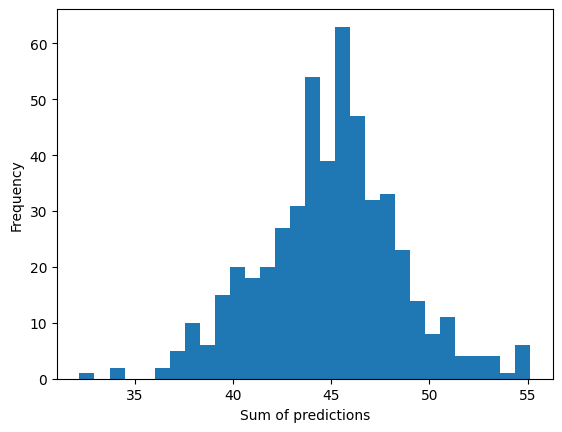

In [32]:
plt.hist(samples.sum(0).numpy(), bins=30)
plt.xlabel("Sum of predictions")
plt.ylabel("Frequency")